<a href="https://colab.research.google.com/github/KaisaridiSofia/leaspy_tutorial/blob/fit_notebook/notebooks/fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
BRANCH = "main"

import importlib.util, pathlib, subprocess, sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None
pip = [sys.executable, "-m", "pip", "install", "-q"]

if IN_COLAB:
    if importlib.util.find_spec("leaspy") is None:
        subprocess.run(pip + ["--no-deps",
    "leaspy @ git+https://github.com/aramis-lab/leaspy.git@v2.1.0"], check=True)
        subprocess.run(pip + ["lifelines"], check=True)   # dep Colab may lack
    if importlib.util.find_spec("fitz") is None:
        subprocess.run(pip + ["pymupdf"], check=True)
    if not pathlib.Path("leaspy_tutorial").exists():
        subprocess.run(["git", "clone", "-q", "--branch", BRANCH,
                        "https://github.com/aramis-lab/leaspy_tutorial"], check=True)
    sys.path.insert(0, "leaspy_tutorial")
else:
    for _root in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (_root / "tutolib").is_dir():
            sys.path.insert(0, str(_root)); break

import tutolib as tp
print("tutolib", tp.__version__, "loaded")

tutolib 0.1.0 loaded


In [75]:
import os

import matplotlib.pyplot as plt
import fitz
from IPython.display import Image, display

import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score

import leaspy
from leaspy.datasets import load_dataset
from leaspy.io.data import Data
from leaspy.models import LogisticModel
from leaspy.io.logs.visualization.plotting import Plotting

print(f"leaspy {leaspy.__version__}")



leaspy 2.1.0


# Data

*just load and split the dataset, more details in the data part of the notebook*

In [76]:
df = load_dataset("parkinson")
FEATURES = ["MDS1_total", "SCOPA_total", "MOCA_total"]
SEED = 0
df = df[FEATURES]
print(df[FEATURES].head())

n_subjects = df.index.get_level_values("ID").unique().shape[0]
print(f"{n_subjects} subjects in the dataset.")

# Train / test split
df_train = df.loc[:"GS-160"][FEATURES]
df_test = df.loc["GS-161":][FEATURES]
data_train = Data.from_dataframe(df_train)
data_test = Data.from_dataframe(df_test)
train_ids = df_train.index.get_level_values("ID").unique()
test_ids = df_test.index.get_level_values("ID").unique()
print(f"Train : {len(train_ids)} subjects")
print(f"Test  : {len(test_ids)} subjects")

                  MDS1_total  SCOPA_total  MOCA_total
ID     TIME                                          
GS-001 71.354607    0.112301     0.160001    0.275257
       71.554604    0.140880     0.135852    0.380934
       72.054604    0.225499     0.211134    0.351172
       73.054604    0.132519     0.245323    0.377842
       73.554604    0.278923     0.223102    0.292768
200 subjects in the dataset.
Train : 160 subjects
Test  : 40 subjects


# Fit

Once we have a dataset that is ready for leaspy, we have to choose which model to fit in our data.

For now the available models are:
- `LogisticModel`
- `LinearModel`
- `JointModel`
- `LogisticMultivariateMixtureModel`

For this example we will run a logistic model. Since we have three scores we will run a multivariate model wo se need to choose beforehand the number of sources.

*Reminder:* The sources represent the groups of scores that evolve in a similar way. It should be a number smaller that the total number of features.

In [77]:
# Load the model
model_2_sources = LogisticModel(name="logistic", source_dimension=2)

In [78]:
# Fit the model

model_2_sources.fit(
        df_train, "mcmc_saem",
        seed=SEED, n_iter=1000, progress_bar=True,
        save_periodicity=50, plot_periodicity=50,
        overwrite_logs_folder=True,
    )


|--------------------------------------------------|   0/1000 iterations

/usr/local/lib/python3.12/dist-packages/leaspy/algo/settings.py:86: UserWarning: Outputs will be saved in '_outputs' relative to the current working directory
  self._create_root_folder(settings)
/usr/local/lib/python3.12/dist-packages/leaspy/algo/settings.py:167: UserWarning: Overwriting '/content/_outputs' folder...
  warnings.warn(f"Overwriting '{path}' folder...")


|############--------------------------------------|   240/1000 iterations================================================================================
                                 Model Summary                                  
Model Name: logistic
Model Type: LogisticModel
Features (3): MDS1_total, SCOPA_total, MOCA_total
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5604.0562
Parameters: 19
BIC: -13535.12
AIC: -13593.55

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 1000

Data Context
--------------------------------------------------------------------------------
Subjects: 160
Visits: 1590
Total Observations: 4770
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1
            b0        0.0492    0.0348

In [79]:
# Save the model
model_2_sources.save("_outputs/model_parameters.json")

## Convergence assessment

The model is estimated via an MCMC-SAEM. It is an iterative algorithm that lies in a stochastic approximation. Before interpreting the results of our fit we should check if the model has converged. In simple words we should see if the final estimations are stable and if the chains had explored adequately the parameter space.

During the fit, the values of the estimated parameters are saved in every `save_periodicity` iterations in .csv files and they are plotted in every `plot_periodicity` iterations in a .pdf file that canbe found in your outputs folder.

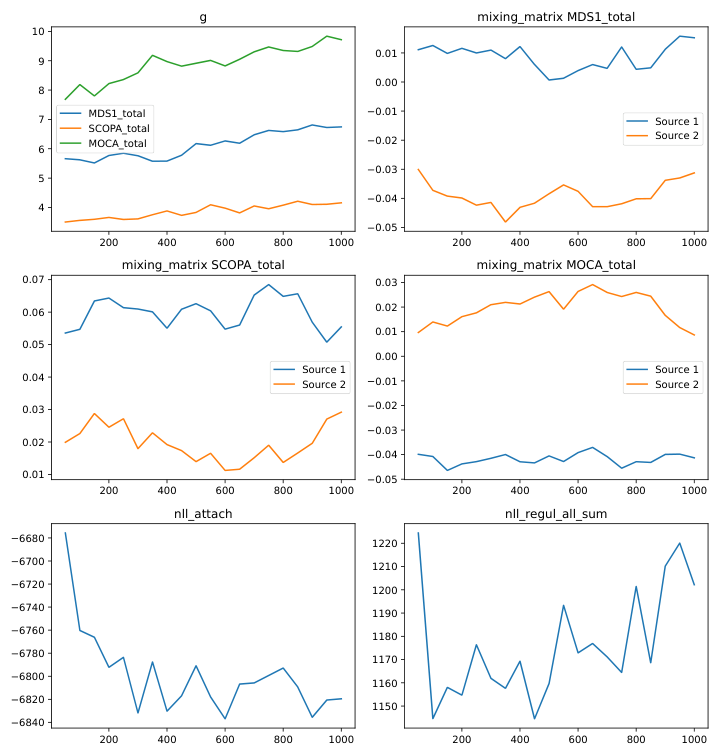

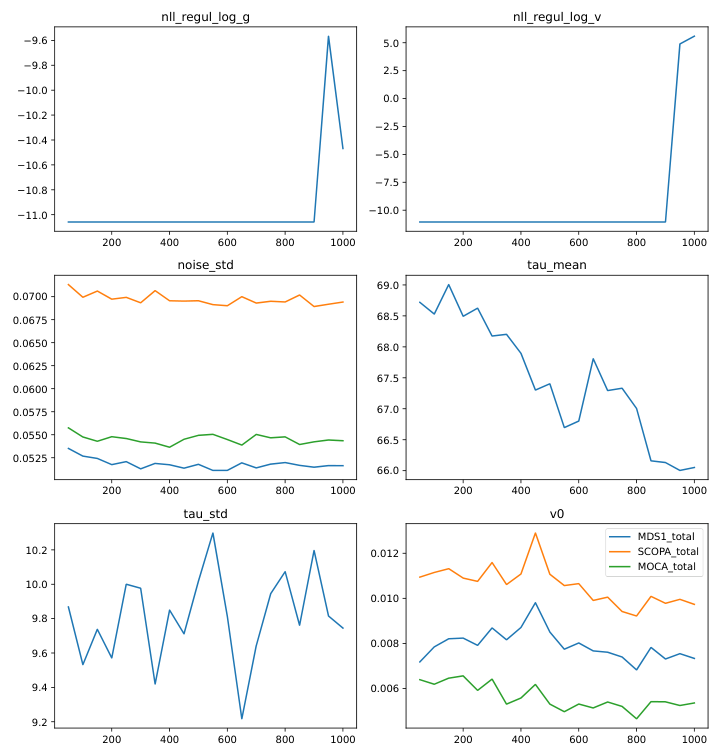

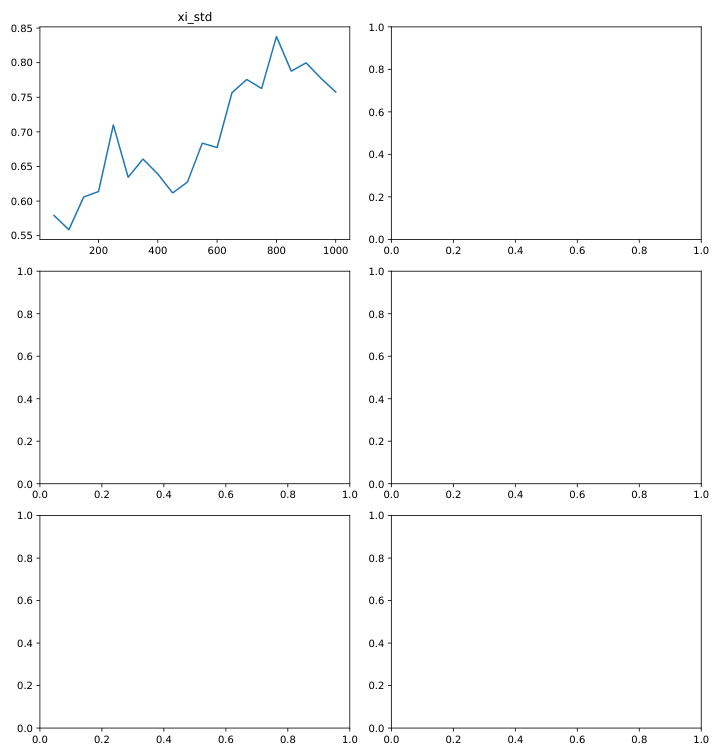

In [80]:
doc = fitz.open("_outputs/plots/convergence_parameters.pdf")

for i, page in enumerate(doc):
    pix = page.get_pixmap()
    img_path = f"convergence_page_{i+1}.png"
    pix.save(img_path)
    display(Image(img_path))

### Question
Do you think it has converged ? If not what might be the issue?

In [81]:
## convergence plot for 100 000 iterations

## Model summary

Once we have a model with a satisfactory convergence. We can take a look at the fir output via the integrated `summary()` function.

In [82]:
model_2_sources.summary()

                                 Model Summary                                  
Model Name: logistic
Model Type: LogisticModel
Features (3): MDS1_total, SCOPA_total, MOCA_total
Sources (2): Source 0 (s0), Source 1 (s1)
Observation Models: gaussian-diagonal
Neg. Log-Likelihood: -5604.0562
Parameters: 19
BIC: -13535.12
AIC: -13593.55

Training Metadata
--------------------------------------------------------------------------------
Algorithm: mcmc_saem
Seed: 0
Iterations: 1000

Data Context
--------------------------------------------------------------------------------
Subjects: 160
Visits: 1590
Total Observations: 4770
Leaspy Version: 2.1.0

Population Parameters
--------------------------------------------------------------------------------
  betas_mean:
                          s0        s1
            b0        0.0492    0.0348
            b1       -0.0462    0.0255
                    MDS1_to.  SCOPA_t.  MOCA_to.
  log_g_mean          1.9108    1.4149    2.2763
                 

We can show specific elements such as the metrics:

In [83]:
print(f"BIC: {float(model_2_sources.summary().bic)}\nAIC: {float(model_2_sources.summary().aic)}")

BIC: -13535.124431885557
AIC: -13593.552734375


Or a specific set of parameters

In [84]:
model_2_sources.summary().parameters['Individual Parameters']

{'tau_mean': tensor([66.0522]),
 'tau_std': tensor([9.7451]),
 'xi_std': tensor([0.7576])}

## Plotting

We can also plot the population trajectories with leaspy's internal plotting tool

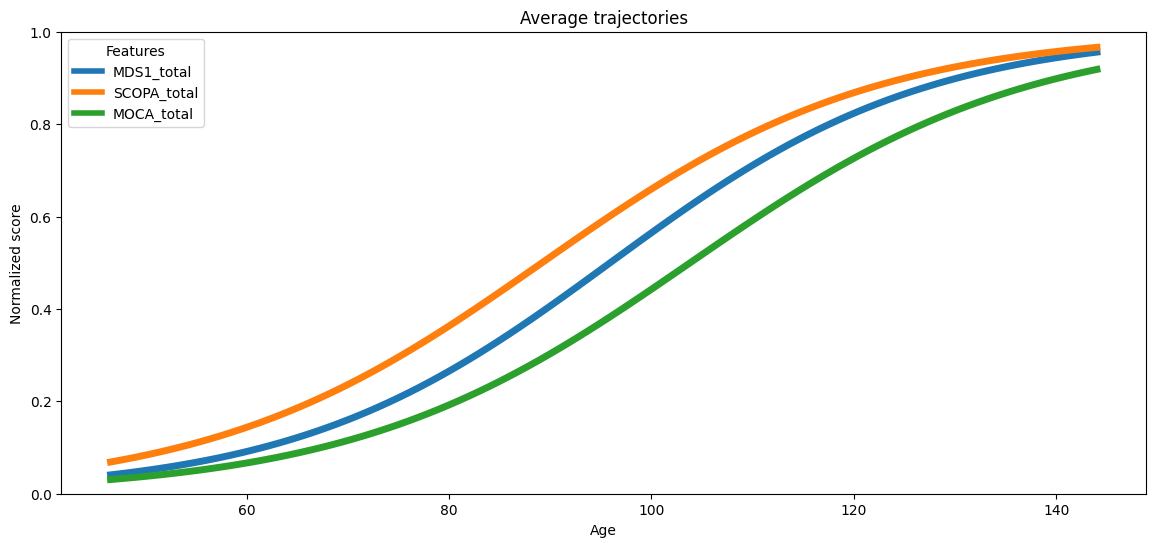

In [85]:
leaspy_plotting = Plotting(model_2_sources)
ax = leaspy_plotting.average_trajectory(alpha=1, figsize=(14, 6), n_std_left=2, n_std_right=8)
plt.show()

## Model Comparison

### Task 1: Vary the number of sources

Can you load and fit a logistic model with one source and compare it with the previous model?

model_1_source = ...

In [86]:
## SOLUTION:

#model_1_source = LogisticModel(name="logistic", source_dimension=1)

#model_1_source.fit(
#        df_train, "mcmc_saem",
#        seed=SEED, n_iter=1000, progress_bar=True,
#        save_periodicity=500, plot_periodicity=500,
#        overwrite_logs_folder=True,
#    )

In [87]:
#print(f"2 sources\nBIC: {float(model_2_sources.summary().bic)}\nAIC: {float(model_2_sources.summary().aic)}")
#print(f"1 source\nBIC: {float(model_1_source.summary().bic)}\nAIC: {float(model_1_source.summary().aic)}")

### Task 2: Vary the noise model

The default choice is to fit a `gaussian-diagonal` noise, which means that we fit a noise with a separate standard deviation per score`


In [88]:
model_1_source.observation_model_names

NameError: name 'model_1_source' is not defined

Another option is to fit a `gaussian-scalar` noise, which means fitting one global standard deviation for the noise shared between all the scores.

We just have to add the argument `obs_models='gaussian-scalar'` when we load our model.

In [ ]:
## SOLUTION:

#model_scalar_1_source = LogisticModel(name="logistic", source_dimension=1, obs_models='gaussian-scalar')

#model_scalar_1_source.fit(
#        df_train, "mcmc_saem",
#        seed=SEED, n_iter=1000, progress_bar=True,
#        save_periodicity=500, plot_periodicity=500,
#        overwrite_logs_folder=True,
#    )

Let's fit also a model with 2 sources and a scalar noise and compare the four models all together.

In [ ]:
## SOLUTION:

#model_scalar_2_sources = LogisticModel(name="logistic", source_dimension=2, obs_models='gaussian-scalar')

#model_scalar_2_sources.fit(
#        df_train, "mcmc_saem",
#        seed=SEED, n_iter=1000, progress_bar=True,
#        save_periodicity=500, plot_periodicity=500,
#        overwrite_logs_folder=True,
#    )

In [ ]:
## SOLUTION:

#print(f"Diagonal noise, 2 sources\nBIC: {float(model_2_sources.summary().bic)}\nAIC: {float(model_2_sources.summary().aic)}")
#print(f"Diagonal noise, 1 source\nBIC: {float(model_1_source.summary().bic)}\nAIC: {float(model_1_source.summary().aic)}")
#print(f"Scalar noise, 2 sources\nBIC: {float(model_scalar_2_sources.summary().bic)}\nAIC: {float(model_scalar_2_sources.summary().aic)}")
#print(f"Scalar noise, 1 source\nBIC: {float(model_scalar_1_source.summary().bic)}\nAIC: {float(model_scalar_1_source.summary().aic)}")